In [8]:
%load_ext autoreload
%autoreload 2

from ble import get_ble_controller
from base_ble import LOG
from cmd_types import CMD
import time
import numpy as np
import pickle
import matplotlib.pyplot as plt
from pathlib import Path

LOG.propagate = False

ble = get_ble_controller()
ble.connect()
print("BLE connected")


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
2026-04-08 15:34:38,493 | INFO     |: Looking for Artemis Nano Peripheral Device: c0:81:c4:22:a9:64
2026-04-08 15:34:38,495 | INFO     |: Scanning for device with address: c0:81:c4:22:a9:64, service UUID: 789d254e-2393-4828-b10b-3952b9ca360b
2026-04-08 15:34:48,516 | INFO     |: Found 1 device(s) advertising service 789d254e-2393-4828-b10b-3952b9ca360b
2026-04-08 15:34:48,517 | INFO     |: Selecting device: 916E591F-7011-B7AC-55D0-A23622AFF175 (name: Artemis BLE)
2026-04-08 15:34:49,566 | INFO     |: Connected to c0:81:c4:22:a9:64
BLE connected


## Notify + Scan Helpers


In [9]:
map_msgs = []
map_status_msgs = []

map_log_active = False
map_log_done = False
map_scan_done = False

last_map_config = {}
all_map_scans = []
map_live_samples = []
map_live_save_path = Path("logs/lab9_live_samples.pkl")
scan_archive_dir = Path("logs/lab9_saved_scans")

def save_live_map_samples():
    payload = {
        "config": last_map_config.copy(),
        "samples": list(map_live_samples),
    }
    map_live_save_path.parent.mkdir(parents=True, exist_ok=True)
    with open(map_live_save_path, "wb") as f:
        pickle.dump(payload, f)

def print_live_map_summary():
    print("Stored live samples:", len(map_live_samples))
    if map_live_samples:
        print("Last sample:", map_live_samples[-1])

def wait_flag(flag_name, timeout_s=20.0, poll_s=0.05):
    t0 = time.time()
    while time.time() - t0 < timeout_s:
        if globals()[flag_name]:
            return True
        time.sleep(poll_s)
    print(f"Timed out waiting for {flag_name}")
    return False

def map_notification_handler(uuid, byte_array):
    global map_msgs, map_status_msgs, map_live_samples
    global map_log_active, map_log_done, map_scan_done

    s = ble.bytearray_to_string(byte_array).strip()
    print(s)
    map_msgs.append(s)

    if s.startswith("MAP_SCAN_STARTED"):
        map_status_msgs.append(s)
        return

    if s.startswith("MAP_STEP_TARGET"):
        map_status_msgs.append(s)
        return

    if s.startswith("MAP_SAMPLE"):
        map_status_msgs.append(s)
        parts = s.split(",")
        if len(parts) == 5:
            sample = {
                "step_idx": int(parts[1]),
                "yaw_deg": float(parts[2]),
                "dist_mm": float(parts[3]),
                "setpoint_deg": float(parts[4]),
            }
            map_live_samples.append(sample)
            save_live_map_samples()
        return

    if s.startswith("MAP_SCAN_DONE"):
        map_status_msgs.append(s)
        save_live_map_samples()
        map_scan_done = True
        return

    if s == "MAP_SCAN_STOPPED":
        map_status_msgs.append(s)
        map_scan_done = True
        return

    if s == "MAP_SCAN_YAW_INVALID":
        map_status_msgs.append(s)
        map_scan_done = True
        return

    if s == "MAP_SCAN_BAD_ARGS":
        map_status_msgs.append(s)
        map_scan_done = True
        return

    if s == "MAP_BEGIN":
        map_log_active = True
        map_log_done = False
        return

    if s.startswith("MAP_END"):
        map_log_active = False
        map_log_done = True
        return

try:
    ble.stop_notify(ble.uuid["RX_STRING"])
except Exception:
    pass

ble.start_notify(ble.uuid["RX_STRING"], map_notification_handler)
print("Map notify started")


Map notify started


In [10]:
def start_map_scan(step_deg=20.0,
                   num_steps=18,
                   kp=0.8,
                   ki=0.001,
                   kd=0.5,
                   settle_ms=150):
    global map_msgs, map_status_msgs, map_live_samples
    global map_log_active, map_log_done, map_scan_done, last_map_config

    map_msgs = []
    map_status_msgs = []
    map_log_active = False
    map_log_done = False
    map_scan_done = False
    map_live_samples = []

    last_map_config = {
        "step_deg": step_deg,
        "num_steps": num_steps,
        "kp": kp,
        "ki": ki,
        "kd": kd,
        "settle_ms": settle_ms,
    }

    save_live_map_samples()

    cmd_str = f"{step_deg}|{num_steps}|{kp}|{ki}|{kd}|{settle_ms}"
    print("Sending:", cmd_str)
    ble.send_command(CMD.START_MAP_SCAN, cmd_str)

def stop_map_scan():
    ble.send_command(CMD.STOP_MAP_SCAN, "")

def request_map_log(timeout_s=15.0):
    global map_log_active, map_log_done
    map_log_active = False
    map_log_done = False
    ble.send_command(CMD.SEND_MAP_SCAN, "")
    return wait_flag("map_log_done", timeout_s=timeout_s)


## Run One Scan


In [170]:
start_map_scan(step_deg=20.0,
               num_steps=19,
               kp=0.8,
               ki=0.001,
               kd=0.2,
               settle_ms=550)

# wait_flag("map_scan_done", timeout_s=15.0)


Sending: 20.0|19|0.8|0.001|0.2|550
MAP_SCAN_STARTED,20.000,19,0.800,0.001,0.200,550,76.396
MAP_SAMPLE,0,76.328,2174.000,76.396
MAP_STEP_TARGET,1,96.396
MAP_SAMPLE,1,96.249,368.000,96.396
MAP_STEP_TARGET,2,116.396
MAP_SAMPLE,2,117.053,414.000,116.396
MAP_STEP_TARGET,3,136.396
MAP_SAMPLE,3,139.438,642.000,136.396
MAP_STEP_TARGET,4,156.396
MAP_SAMPLE,4,153.970,2399.000,156.396
MAP_STEP_TARGET,5,176.396
MAP_SAMPLE,5,173.503,2695.000,176.396
MAP_STEP_TARGET,6,-163.603
MAP_SAMPLE,6,-165.678,1219.000,-163.603
MAP_STEP_TARGET,7,-143.603
MAP_SAMPLE,7,-145.240,674.000,-143.603
MAP_STEP_TARGET,8,-123.603
MAP_SAMPLE,8,-125.074,468.000,-123.603
MAP_STEP_TARGET,9,-103.603
MAP_SAMPLE,9,-105.516,394.000,-103.603
MAP_STEP_TARGET,10,-83.603
MAP_SAMPLE,10,-85.682,383.000,-83.603
MAP_STEP_TARGET,11,-63.603
MAP_SAMPLE,11,-64.712,450.000,-63.603
MAP_STEP_TARGET,12,-43.603
MAP_SAMPLE,12,-45.798,631.000,-43.603
MAP_STEP_TARGET,13,-23.603
MAP_SAMPLE,13,-24.653,513.000,-23.603
MAP_STEP_TARGET,14,-3.603
MAP_SAMP

In [171]:
request_map_log(timeout_s=15.0)

Timed out waiting for map_log_done


False

MAP_BEGIN
MAP,0,554,76.328,2174.000,76.396
MAP,1,1391,96.249,368.000,96.396
MAP,2,2280,117.053,414.000,116.396
MAP,3,3171,139.438,642.000,136.396
MAP,4,4170,153.970,2399.000,156.396
MAP,5,5268,173.503,2695.000,176.396
MAP,6,7055,-165.678,1219.000,-163.603
MAP,7,8571,-145.240,674.000,-143.603
MAP,8,9515,-125.074,468.000,-123.603
MAP,9,10563,-105.516,394.000,-103.603
MAP,10,11559,-85.682,383.000,-83.603
MAP,11,12508,-64.712,450.000,-63.603
MAP,12,13450,-45.798,631.000,-43.603
MAP,13,14442,-24.653,513.000,-23.603
MAP,14,15386,-5.440,471.000,-3.603
MAP,15,16430,13.614,491.000,16.396
MAP,16,17435,36.724,673.000,36.396
MAP,17,18479,53.944,1080.000,56.396
MAP,18,19371,77.095,2250.000,76.396
MAP_END,19


In [172]:
print_live_map_summary()
print("Autosaved live samples to:", map_live_save_path)

Stored live samples: 19
Last sample: {'step_idx': 18, 'yaw_deg': 77.095, 'dist_mm': 2250.0, 'setpoint_deg': 76.396}
Autosaved live samples to: logs/lab9_live_samples.pkl


## Parse + Polar Plot


In [173]:
step_idx_list = []
t_ms_list = []
yaw_deg_list = []
dist_mm_list = []
setpoint_deg_list = []

for msg in map_msgs:
    if msg.startswith("MAP,"):
        parts = msg.split(",")
        if len(parts) == 6:
            step_idx_list.append(int(parts[1]))
            t_ms_list.append(float(parts[2]))
            yaw_deg_list.append(float(parts[3]))
            dist_mm_list.append(float(parts[4]))
            setpoint_deg_list.append(float(parts[5]))

step_idx = np.array(step_idx_list, dtype=int)
t_ms = np.array(t_ms_list, dtype=float)
yaw_deg = np.array(yaw_deg_list, dtype=float)
dist_mm = np.array(dist_mm_list, dtype=float)
setpoint_deg = np.array(setpoint_deg_list, dtype=float)

if len(step_idx) == 0:
    raise ValueError("No MAP log samples found. Run the scan and request the log first.")

yaw_rel_deg = (yaw_deg - yaw_deg[0] + 180.0) % 360.0 - 180.0
theta_rad = np.deg2rad(yaw_rel_deg)

print("N =", len(step_idx))
print("step idx range =", int(np.min(step_idx)), "to", int(np.max(step_idx)))
print("yaw rel range =", float(np.min(yaw_rel_deg)), "to", float(np.max(yaw_rel_deg)), "deg")
print("dist range =", float(np.min(dist_mm)), "to", float(np.max(dist_mm)), "mm")


N = 19
step idx range = 0 to 18
yaw rel range = -162.01 to 178.156 deg
dist range = 368.0 to 2695.0 mm


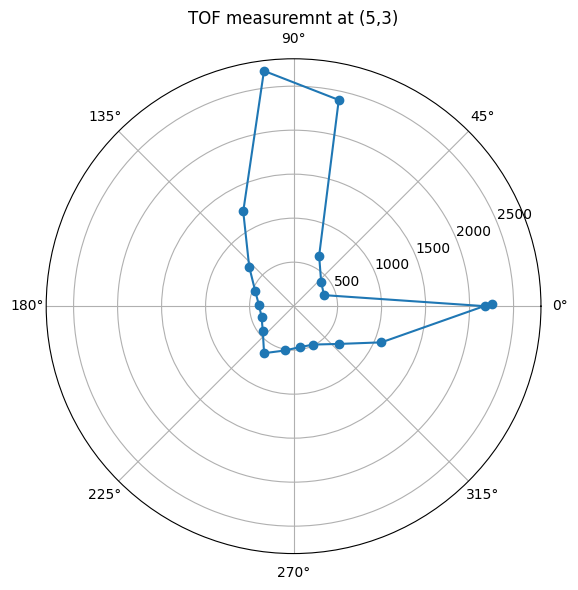

In [185]:
fig = plt.figure(figsize=(6, 6))
ax = plt.subplot(111, projection="polar")
ax.plot(theta_rad, dist_mm, marker="o", linewidth=1.5)
ax.set_title("TOF measuremnt at (5,3)")
ax.set_theta_zero_location("E")
ax.grid(True)
plt.tight_layout()
plt.show()


## World-Frame Transform


In [175]:
def wrap_deg(angle_deg):
    arr = np.asarray(angle_deg, dtype=float)
    return (arr + 180.0) % 360.0 - 180.0

def make_T(x_mm, y_mm, theta_deg):
    th = np.deg2rad(theta_deg)
    return np.array([
        [np.cos(th), -np.sin(th), x_mm],
        [np.sin(th),  np.cos(th), y_mm],
        [0.0,         0.0,        1.0],
    ])

def scan_to_world_points(dist_mm, yaw_deg, robot_pose_mm=(0.0, 0.0, 0.0), sensor_pose_mm=(0.0, 0.0, 0.0)):
    dist_mm = np.asarray(dist_mm, dtype=float)
    yaw_deg = np.asarray(yaw_deg, dtype=float)
    yaw_rel_deg = wrap_deg(yaw_deg - yaw_deg[0])

    x_world_mm = []
    y_world_mm = []

    for d_mm, yaw_rel in zip(dist_mm, yaw_rel_deg):
        T_world_robot = make_T(robot_pose_mm[0], robot_pose_mm[1], robot_pose_mm[2] + yaw_rel)
        T_robot_sensor = make_T(sensor_pose_mm[0], sensor_pose_mm[1], sensor_pose_mm[2])
        p_sensor = np.array([d_mm, 0.0, 1.0])
        p_world = T_world_robot @ T_robot_sensor @ p_sensor
        x_world_mm.append(p_world[0])
        y_world_mm.append(p_world[1])

    return np.array(x_world_mm), np.array(y_world_mm), yaw_rel_deg

def store_current_scan(robot_pose_mm=(0.0, 0.0, 0.0), sensor_pose_mm=(0.0, 0.0, 0.0), label=None):
    x_world_mm, y_world_mm, yaw_rel_deg_local = scan_to_world_points(
        dist_mm,
        yaw_deg,
        robot_pose_mm=robot_pose_mm,
        sensor_pose_mm=sensor_pose_mm,
    )

    scan = {
        "label": label,
        "config": last_map_config.copy(),
        "robot_pose_mm": tuple(robot_pose_mm),
        "sensor_pose_mm": tuple(sensor_pose_mm),
        "step_idx": step_idx.copy(),
        "t_ms": t_ms.copy(),
        "yaw_deg": yaw_deg.copy(),
        "yaw_rel_deg": yaw_rel_deg_local.copy(),
        "dist_mm": dist_mm.copy(),
        "setpoint_deg": setpoint_deg.copy(),
        "x_world_mm": x_world_mm.copy(),
        "y_world_mm": y_world_mm.copy(),
    }

    all_map_scans.append(scan)
    return scan

def sanitize_scan_name(scan_name):
    safe_name = "".join(ch if ch.isalnum() or ch in "-_." else "_" for ch in str(scan_name).strip())
    if not safe_name:
        raise ValueError("scan_name cannot be empty")
    return safe_name

def save_scan_snapshot(scan_name,
                       robot_pose_mm=(0.0, 0.0, 0.0),
                       sensor_pose_mm=(0.0, 0.0, 0.0),
                       label=None):
    safe_name = sanitize_scan_name(scan_name)
    if label is None:
        label = safe_name

    scan = store_current_scan(robot_pose_mm=robot_pose_mm,
                              sensor_pose_mm=sensor_pose_mm,
                              label=label)

    scan_archive_dir.mkdir(parents=True, exist_ok=True)
    out_path = scan_archive_dir / f"{safe_name}.pkl"
    with open(out_path, "wb") as f:
        pickle.dump(scan, f)

    print("Saved scan to:", out_path)
    return scan, out_path

def plot_all_world_scans(scans):
    plt.figure(figsize=(7, 7))
    for i, scan in enumerate(scans):
        label = scan["label"] if scan["label"] is not None else f"scan_{i}"
        plt.scatter(scan["x_world_mm"], scan["y_world_mm"], s=18, label=label)
    plt.axis("equal")
    plt.grid(True)
    plt.xlabel("x (mm)")
    plt.ylabel("y (mm)")
    plt.title("Lab9 Multi-Scan World Plot")
    if len(scans) > 0:
        plt.legend()
    plt.tight_layout()
    plt.show()


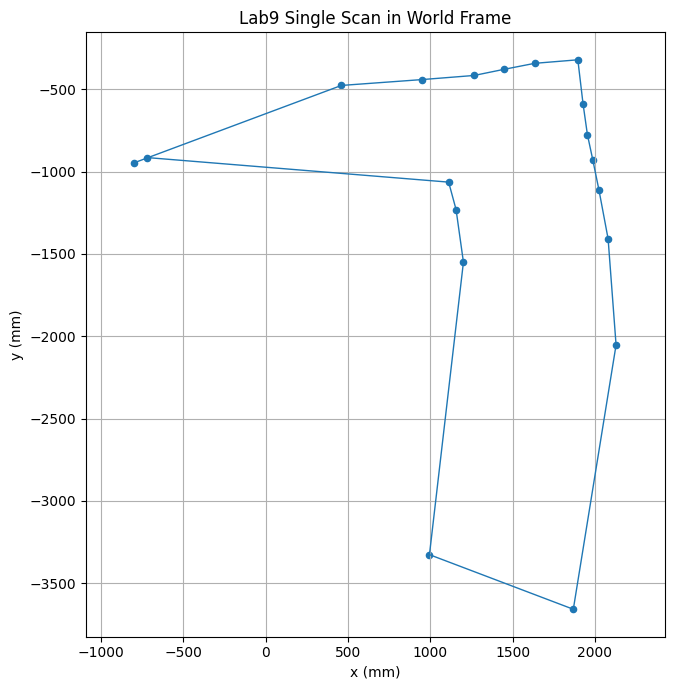

Saved scan to: logs/lab9_saved_scans/5_neg3_test.pkl
Stored scan count: 25
Saved named scan: logs/lab9_saved_scans/5_neg3_test.pkl


In [188]:
scan_name = "5_neg3_test"
robot_pose_mm = (5 * 304.8, -3 * 304.8, -180.0)
sensor_pose_mm = (70.0, 0.0, 0.0)  # Update after measuring the front ToF offset from robot center.

x_world_mm, y_world_mm, yaw_rel_deg = scan_to_world_points(
    dist_mm,
    yaw_deg,
    robot_pose_mm=robot_pose_mm,
    sensor_pose_mm=sensor_pose_mm,
)

plt.figure(figsize=(7, 7))
plt.scatter(x_world_mm, y_world_mm, s=20)
plt.plot(x_world_mm, y_world_mm, linewidth=1.0)
plt.axis("equal")
plt.grid(True)
plt.xlabel("x (mm)")
plt.ylabel("y (mm)")
plt.title("Lab9 Single Scan in World Frame")
plt.tight_layout()
plt.show()

current_scan, current_scan_path = save_scan_snapshot(scan_name,
                                                     robot_pose_mm=robot_pose_mm,
                                                     sensor_pose_mm=sensor_pose_mm)
print("Stored scan count:", len(all_map_scans))
print("Saved named scan:", current_scan_path)


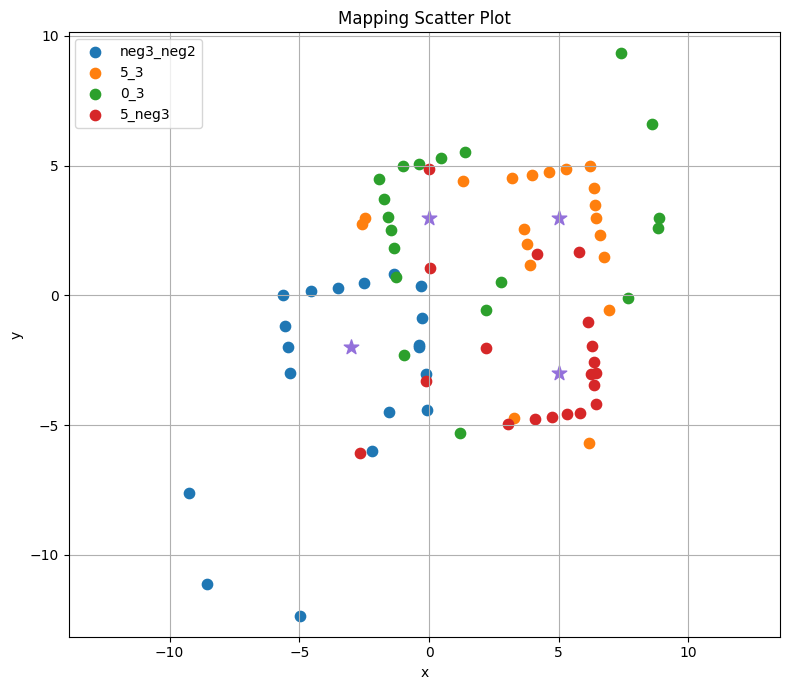

In [191]:
import pickle
from pathlib import Path
import matplotlib.pyplot as plt

scan_dir = Path("logs/lab9_saved_scans")
scan_files = [
    scan_dir / "neg3_neg2.pkl",
    scan_dir / "5_3.pkl",
    scan_dir / "0_3.pkl",
    scan_dir / "5_neg3.pkl",
]

scans = []
for path in scan_files:
    with open(path, "rb") as f:
        scans.append(pickle.load(f))

plt.figure(figsize=(8, 7))

for scan in scans:
    x_ft = scan["x_world_mm"] / 304.8
    y_ft = scan["y_world_mm"] / 304.8
    rx_ft = scan["robot_pose_mm"][0] / 304.8
    ry_ft = scan["robot_pose_mm"][1] / 304.8

    plt.scatter(x_ft, y_ft, s=55, label=scan["label"])
    plt.scatter(rx_ft, ry_ft, marker="*", s=120, c="mediumpurple")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Mapping Scatter Plot")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


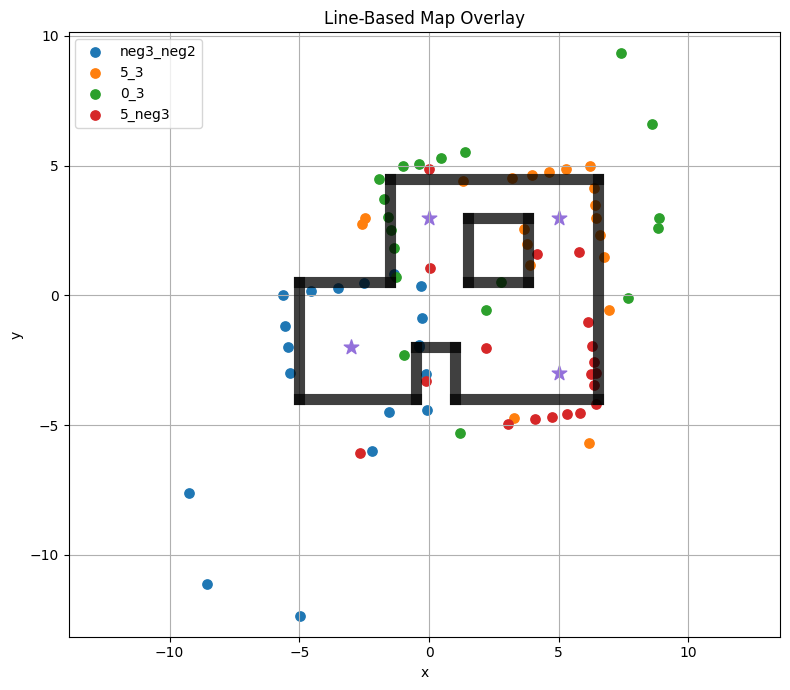

In [192]:
starts_ft = [
    (-5, -4),
    (-0.5, -4),
    (-0.5, -2),
    (1, -2),
    (1, -4),
    (6.5, -4),
    (6.5, 4.5),
    (-1.5, 4.5),
    (-1.5, 0.5),
    (-5, 0.5),
    (1.5, 0.5),
    (1.5, 3),
    (3.8, 3),
    (3.8, 0.5),   
]

ends_ft = [
    (-0.5, -4),
    (-0.5, -2),
    (1, -2),
    (1, -4),
    (6.5, -4),
    (6.5, 4.5),
    (-1.5, 4.5),
    (-1.5, 0.5),
    (-5, 0.5),
    (-5, -4),
    (1.5, 3),
    (3.8, 3),
    (3.8, 0.5),
    (1.5, 0.5), 
]


plt.figure(figsize=(8, 7))

for scan in scans:
    x_ft = scan["x_world_mm"] / 304.8
    y_ft = scan["y_world_mm"] / 304.8
    rx_ft = scan["robot_pose_mm"][0] / 304.8
    ry_ft = scan["robot_pose_mm"][1] / 304.8

    plt.scatter(x_ft, y_ft, s=45, label=scan["label"])
    plt.scatter(rx_ft, ry_ft, marker="*", s=120, c="mediumpurple")

for (x0, y0), (x1, y1) in zip(starts_ft, ends_ft):
    plt.plot([x0, x1], [y0, y1], color="black", linewidth=8, alpha=0.75)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Line-Based Map Overlay")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


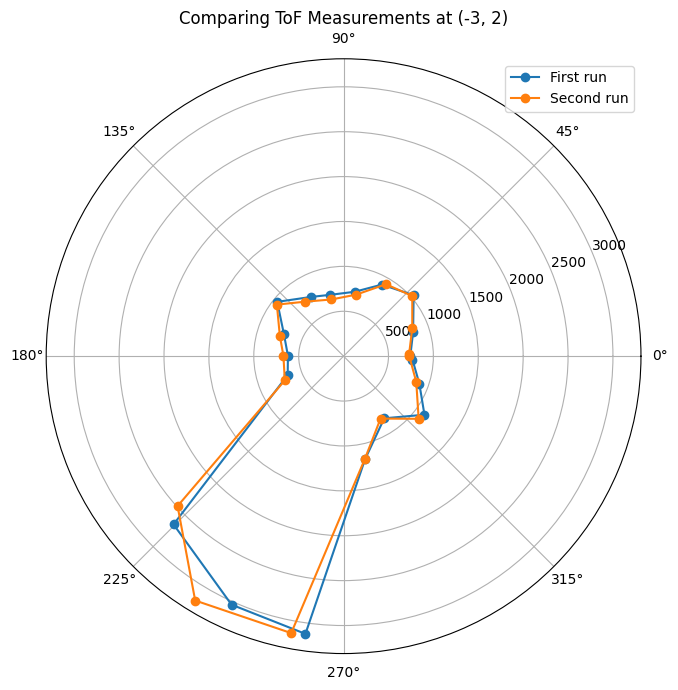

In [87]:
import pickle
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# 第一次已经保存好的 5,-3 扫描
first_scan_path = Path("logs/lab9_saved_scans/neg3_2.pkl")

with open(first_scan_path, "rb") as f:
    first_scan = pickle.load(f)

# 第一次保存的数据
first_yaw = np.array(first_scan["yaw_deg"], dtype=float)
first_dist = np.array(first_scan["dist_mm"], dtype=float)

# 第二次刚跑完、但还没保存的数据
second_yaw = np.array(yaw_deg, dtype=float)
second_dist = np.array(dist_mm, dtype=float)

# 都转成“相对本次起始朝向”的角度，方便公平比较
first_yaw_rel = wrap_deg(first_yaw - first_yaw[0])
second_yaw_rel = wrap_deg(second_yaw - second_yaw[0])

first_theta = np.deg2rad((first_yaw_rel + 360) % 360)
second_theta = np.deg2rad((second_yaw_rel + 360) % 360)

plt.figure(figsize=(7, 7))
ax = plt.subplot(111, projection="polar")

ax.plot(first_theta, first_dist, marker="o", label="First run")
ax.plot(second_theta, second_dist, marker="o", label="Second run")

ax.set_title("Comparing ToF Measurements at (-3, 2)")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()
